# Librairy

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import combinations

# Data's import

## Data from 51_BC_WITHIN_5Y_GeneticAncestry_Treatment

* Femmes n'ayant pas eu de cancer avant l'inclusion (BC and not BC included without time constraints) for all time)
* Origine génétique (RYE)

In [2]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry.tsv"

# copy csv file from the bucket to the current working space
os.system(f"gsutil cp 'gs://fc-secure-4f907dc3-1aa1-4aaa-8566-86d601589221/Data/df_all_prs_298_305_311.csv' .")

print(f'[INFO] {name_of_file_in_bucket} is successfully downloaded into your working space')
# save dataframe in a csv file in the same workspace as the notebook
df_bc = pd.read_csv(name_of_file_in_bucket)
df_bc

Copying gs://fc-secure-4f907dc3-1aa1-4aaa-8566-86d601589221/Data/df_all_prs_298_305_311.csv...
- [1 files][ 62.2 MiB/ 62.2 MiB]                                                
Operation completed over 1 objects/62.2 MiB.                                     


[INFO] df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry.tsv is successfully downloaded into your working space


,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,has_bc,research_id,eur_rye,eas_rye,amr_rye,afr_rye,sas_rye,mid_rye,dominant_origin,ancestry_80
0,2028403,Female,1934-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-11-15,NaN,NaN,NaN,NaN,...,0,2028403.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,amr_rye,amr_rye
1,7685408,Female,2002-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2022-11-03,NaN,NaN,NaN,NaN,...,0,7685408.0,0.177068,0.352607,0.024190,0.000000,0.230819,0.215316,eas_rye,admixed
2,2299281,Female,1937-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-03-06,NaN,NaN,NaN,NaN,...,0,2299281.0,0.067481,0.000000,0.015771,0.000000,0.916749,0.000000,sas_rye,sas_rye
3,2047635,Female,1941-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-11-09,NaN,NaN,NaN,NaN,...,0,2047635.0,0.910879,0.004663,0.020749,0.000000,0.042325,0.021384,eur_rye,eur_rye
4,1608049,Female,1939-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-10-29,NaN,NaN,NaN,NaN,...,0,1608049.0,0.037236,0.011586,0.000000,0.890096,0.000000,0.061081,afr_rye,afr_rye
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,4319948,Female,2001-06-15,Not Hispanic or Latino,White,2023-05-24,NaN,NaN,NaN,NaN,...,0,4319948.0,0.881773,0.000000,0.054992,0.000000,0.056850,0.006386,eur_rye,eur_rye
223202,9726693,Female,2001-06-15,Not Hispanic or Latino,White,2021-10-22,NaN,NaN,NaN,NaN,...,0,9726693.0,0.952240,0.000000,0.035841,0.000000,0.011918,0.000000,eur_rye,eur_rye
223203,3338506,Female,2001-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,0,3338506.0,0.948308,0.000000,0.024919,0.000000,0.026773,0.000000,eur_rye,eur_rye
223204,8355512,Female,2001-06-15,Not Hispanic or Latino,White,2023-03-14,NaN,NaN,NaN,NaN,...,0,8355512.0,0.921728,0.000000,0.050576,0.000000,0.000438,0.027258,eur_rye,eur_rye


# Biopsy data processing

Le principe de prendre la biopsie comme marqueur de risque, c’est la biopsie au sens diagnostique

## Biopsy 19081-19086

**19081 -> 19086 :** Biopsy, breast, with placement of breast localization device(s) (eg, clip, metallic pellet), when performed, and imaging of the biopsy specimen, when performed, percutaneous; :
* **19081 ->** [..] first lesion, **including stereotactic guidance**
* **19082 ->** [..] each additional lesion, **stereotactic guidance** (List separately additi...)
* **19083 ->** [..] first lesions, **including ultrasound guidance**
* **19084 ->**  [..] each additional lesion, **including ultrasound guidance** (List separately additi...)
* **19085 ->** [..] first lesions, **including magnetic resonance guidance**
* **19086 ->**  [..] each additional lesion, **including magnetic resonance guidance** (List separately additi...)

### Importing Biopsy data

In [3]:
# This query represents dataset "biopsy 19081-19086" for domain "procedure" and was generated for All of Us Controlled Tier Dataset v8
dataset_82834044_procedure_sql = """
    SELECT
        procedure.person_id,
        procedure.procedure_concept_id,
        p_standard_concept.concept_name as standard_concept_name,
        p_standard_concept.concept_code as standard_concept_code,
        p_standard_concept.vocabulary_id as standard_vocabulary,
        procedure.procedure_datetime,
        procedure.procedure_type_concept_id,
        p_type.concept_name as procedure_type_concept_name,
        procedure.modifier_concept_id,
        p_modifier.concept_name as modifier_concept_name,
        procedure.quantity,
        procedure.visit_occurrence_id,
        p_visit.concept_name as visit_occurrence_concept_name,
        procedure.procedure_source_value,
        procedure.procedure_source_concept_id,
        p_source_concept.concept_name as source_concept_name,
        p_source_concept.concept_code as source_concept_code,
        p_source_concept.vocabulary_id as source_vocabulary,
        procedure.modifier_source_value 
    FROM
        ( SELECT
            * 
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.procedure_occurrence` procedure 
        WHERE
            (
                procedure_source_concept_id IN (SELECT
                    DISTINCT c.concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                JOIN
                    (SELECT
                        CAST(cr.id as string) AS id       
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                    WHERE
                        concept_id IN (44816374, 44816375, 44816376, 44816377, 44816378, 44816379)       
                        AND full_text LIKE '%_rank1]%'      ) a 
                        ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                        OR c.path LIKE CONCAT('%.', a.id) 
                        OR c.path LIKE CONCAT(a.id, '.%') 
                        OR c.path = a.id) 
                WHERE
                    is_standard = 0 
                    AND is_selectable = 1)
            )) procedure 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_standard_concept 
            ON procedure.procedure_concept_id = p_standard_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_type 
            ON procedure.procedure_type_concept_id = p_type.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_modifier 
            ON procedure.modifier_concept_id = p_modifier.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.visit_occurrence` v 
            ON procedure.visit_occurrence_id = v.visit_occurrence_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_visit 
            ON v.visit_concept_id = p_visit.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_source_concept 
            ON procedure.procedure_source_concept_id = p_source_concept.concept_id"""

dataset_82834044_procedure_df = pd.read_gbq(
    dataset_82834044_procedure_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_82834044_procedure_df

Downloading:   0%|          | 0/18354 [00:00<?, ?rows/s]

,person_id,procedure_concept_id,standard_concept_name,standard_concept_code,standard_vocabulary,procedure_datetime,procedure_type_concept_id,procedure_type_concept_name,modifier_concept_id,modifier_concept_name,quantity,visit_occurrence_id,visit_occurrence_concept_name,procedure_source_value,procedure_source_concept_id,source_concept_name,source_concept_code,source_vocabulary,modifier_source_value
0,2057066,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,2020-08-31 00:00:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19081,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,No matching concept
1,8618455,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,2018-05-07 00:00:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19081,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,No matching concept
2,1502044,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,2023-05-15 18:33:00+00:00,38000275,EHR order list entry,0,No matching concept,1,<NA>,None,19081,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,No matching concept
3,2976379,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,2021-12-09 15:53:00+00:00,38000275,EHR order list entry,0,No matching concept,1,<NA>,None,19081,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,No matching concept
4,1721618,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,2022-05-23 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19081,44816374,"Biopsy, breast, with placement of breast local...",19081,CPT4,No matching concept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18349,8994146,44816376,"Biopsy, breast, with placement of breast local...",19083,CPT4,2022-03-29 00:00:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19083,44816376,"Biopsy, breast, with placement of breast local...",19083,CPT4,No matching concept
18350,2893193,44816376,"Biopsy, breast, with placement of breast local...",19083,CPT4,2021-12-20 14:16:00+00:00,38000275,EHR order list entry,0,No matching concept,1,<NA>,None,19083,44816376,"Biopsy, breast, with placement of breast local...",19083,CPT4,No matching concept
18351,1787812,44816376,"Biopsy, breast, with placement of breast local...",19083,CPT4,2016-03-02 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19083,44816376,"Biopsy, breast, with placement of breast local...",19083,CPT4,No matching concept
18352,2859851,44816376,"Biopsy, breast, with placement of breast local...",19083,CPT4,2023-04-11 20:18:00+00:00,38000275,EHR order list entry,0,No matching concept,1,<NA>,None,19083,44816376,"Biopsy, breast, with placement of breast local...",19083,CPT4,No matching concept


### Have individuals reported multiple biopsy diagnoses ?

In [4]:
# Nombre de déclaration par individu
dataset_82834044_procedure_df[['person_id']].value_counts()

person_id
2117870      27
2024344      24
2039414      24
1267280      24
1035618      24
             ..
2286690       1
2285895       1
2284520       1
2283581       1
2507657       1
Name: count, Length: 8719, dtype: int64

In [5]:
# Observation des biopsies unique pour un individu qui en a déclaré plusieurs
dataset_82834044_procedure_df[dataset_82834044_procedure_df['person_id'] == 2117870].drop_duplicates()[['person_id','procedure_datetime','visit_occurrence_id']]

,person_id,procedure_datetime,visit_occurrence_id
6057,2117870,2018-12-06 00:00:00+00:00,31000000000179900
6121,2117870,2018-12-06 00:00:00+00:00,31000000000179904
12177,2117870,2018-12-06 00:00:00+00:00,31000000000179900
12790,2117870,2018-12-06 00:00:00+00:00,31000000000179904
15472,2117870,2021-05-18 00:00:00+00:00,31000000000176456


### Management of biopsy dates (adding a column for each date)

#### Define a function

In [6]:
def process_procedure_dates(procedure_df, date_col='procedure_datetime', n_dates=3, prefix='biopsy', main_set=df_bc):
    """
    Transforme un DataFrame de procédures (format long) en un résumé par individu (format wide)
    en ne gardant que les N premières dates uniques.
    """
    # 1. Copie pour éviter de modifier l'original et conversion datetime
    df_temp = procedure_df.copy()
    df_temp[date_col] = pd.to_datetime(df_temp[date_col])
    
    # 2. Récupération des dates uniques triées par patient
    # On utilise .dt.date pour ignorer l'heure si elle n'est pas nécessaire
    unique_dates = df_temp.groupby('person_id')[date_col] \
                    .apply(lambda x: sorted(x.unique())) \
                    .reset_index()
    
    # 3. Création des colonnes séparées
    # On transforme la liste de dates en colonnes
    dates_expanded = pd.DataFrame(unique_dates[date_col].tolist(), index=unique_dates.index)
    
    # On ne garde que les N premières colonnes disponibles
    dates_expanded = dates_expanded.iloc[:, :n_dates]
    
    # Renommage dynamique des colonnes
    new_col_names = [f'date_{i+1}_of_{prefix}' for i in range(dates_expanded.shape[1])]
    dates_expanded.columns = new_col_names
    
    # 4. Reconstruction finale avec person_id
    result = pd.concat([unique_dates['person_id'], dates_expanded], axis=1)
    
    # 5. Ajout d'une colonne binaire simple pour faciliter les filtres rapides
    result[f'has_{prefix}'] = 1
    
    # 6. Fusion avec votre DataFrame principal (df)
    final_result = pd.merge(main_set, result, on='person_id', how='left')
    
    # 7. Remplissage des 0 pour ceux qui n'ont pas eu de biopsie
    final_result[f'has_{prefix}'] = final_result[f'has_{prefix}'].fillna(0).astype(int)
    
    return final_result

#### Application of the function

In [7]:
df_biopsy_19081_19086 = process_procedure_dates(
    dataset_82834044_procedure_df,
    n_dates=3,
    prefix='biopsy_19081_19086',
    main_set=df_bc)

df_biopsy_19081_19086

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,amr_rye,afr_rye,sas_rye,mid_rye,dominant_origin,ancestry_80,date_1_of_biopsy_19081_19086,date_2_of_biopsy_19081_19086,date_3_of_biopsy_19081_19086,has_biopsy_19081_19086
0,2028403,Female,1934-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-11-15,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,0.000000,amr_rye,amr_rye,NaT,NaT,NaT,0
1,7685408,Female,2002-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2022-11-03,NaN,NaN,NaN,NaN,...,0.024190,0.000000,0.230819,0.215316,eas_rye,admixed,NaT,NaT,NaT,0
2,2299281,Female,1937-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-03-06,NaN,NaN,NaN,NaN,...,0.015771,0.000000,0.916749,0.000000,sas_rye,sas_rye,NaT,NaT,NaT,0
3,2047635,Female,1941-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-11-09,NaN,NaN,NaN,NaN,...,0.020749,0.000000,0.042325,0.021384,eur_rye,eur_rye,NaT,NaT,NaT,0
4,1608049,Female,1939-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-10-29,NaN,NaN,NaN,NaN,...,0.000000,0.890096,0.000000,0.061081,afr_rye,afr_rye,NaT,NaT,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,4319948,Female,2001-06-15,Not Hispanic or Latino,White,2023-05-24,NaN,NaN,NaN,NaN,...,0.054992,0.000000,0.056850,0.006386,eur_rye,eur_rye,NaT,NaT,NaT,0
223202,9726693,Female,2001-06-15,Not Hispanic or Latino,White,2021-10-22,NaN,NaN,NaN,NaN,...,0.035841,0.000000,0.011918,0.000000,eur_rye,eur_rye,NaT,NaT,NaT,0
223203,3338506,Female,2001-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,0.024919,0.000000,0.026773,0.000000,eur_rye,eur_rye,NaT,NaT,NaT,0
223204,8355512,Female,2001-06-15,Not Hispanic or Latino,White,2023-03-14,NaN,NaN,NaN,NaN,...,0.050576,0.000000,0.000438,0.027258,eur_rye,eur_rye,NaT,NaT,NaT,0


In [8]:
df_biopsy_19081_19086['has_biopsy_19081_19086'].value_counts()

has_biopsy_19081_19086
0    219132
1      4074
Name: count, dtype: int64

### Percentage of individuals who underwent a biopsy (19081-19086)

In [9]:
total_biopsy = df_biopsy_19081_19086[df_biopsy_19081_19086['has_biopsy_19081_19086'] == 1].value_counts('has_bc')[1]

(total_biopsy/df_biopsy_19081_19086.shape[0])*100

0.2311765812746969

## Biopsy 19100-19103

**19100 -> 19103 :**
* **19100 ->** Biopsy of breast; percutaneous, needle core, not using imaging guidance (separate procedure)
* **19101 ->** Biopsy of breast; open, incisional
* **19102 ->** Biopsy of breast; percutaneous, needle core, using imaging guidance
* **19103 ->** Biopsy of breast; percutaneous, automated vacuum assisted or rotating biopsy device, using imaging guidance

### Importing Biopsy data

In [10]:
import pandas
import os

# This query represents dataset "Biopsy (19100-19103" for domain "procedure" and was generated for All of Us Controlled Tier Dataset v8
dataset_03190855_procedure_sql = """
    SELECT
        procedure.person_id,
        procedure.procedure_concept_id,
        p_standard_concept.concept_name as standard_concept_name,
        p_standard_concept.concept_code as standard_concept_code,
        p_standard_concept.vocabulary_id as standard_vocabulary,
        procedure.procedure_datetime,
        procedure.procedure_type_concept_id,
        p_type.concept_name as procedure_type_concept_name,
        procedure.modifier_concept_id,
        p_modifier.concept_name as modifier_concept_name,
        procedure.quantity,
        procedure.visit_occurrence_id,
        p_visit.concept_name as visit_occurrence_concept_name,
        procedure.procedure_source_value,
        procedure.procedure_source_concept_id,
        p_source_concept.concept_name as source_concept_name,
        p_source_concept.concept_code as source_concept_code,
        p_source_concept.vocabulary_id as source_vocabulary,
        procedure.modifier_source_value 
    FROM
        ( SELECT
            * 
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.procedure_occurrence` procedure 
        WHERE
            (
                procedure_source_concept_id IN (SELECT
                    DISTINCT c.concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                JOIN
                    (SELECT
                        CAST(cr.id as string) AS id       
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                    WHERE
                        concept_id IN (2102672, 2102673, 2102674, 2102675)       
                        AND full_text LIKE '%_rank1]%'      ) a 
                        ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                        OR c.path LIKE CONCAT('%.', a.id) 
                        OR c.path LIKE CONCAT(a.id, '.%') 
                        OR c.path = a.id) 
                WHERE
                    is_standard = 0 
                    AND is_selectable = 1)
            )) procedure 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_standard_concept 
            ON procedure.procedure_concept_id = p_standard_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_type 
            ON procedure.procedure_type_concept_id = p_type.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_modifier 
            ON procedure.modifier_concept_id = p_modifier.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.visit_occurrence` v 
            ON procedure.visit_occurrence_id = v.visit_occurrence_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_visit 
            ON v.visit_concept_id = p_visit.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_source_concept 
            ON procedure.procedure_source_concept_id = p_source_concept.concept_id"""

dataset_03190855_procedure_df = pd.read_gbq(
    dataset_03190855_procedure_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_03190855_procedure_df

Downloading:   0%|          | 0/4305 [00:00<?, ?rows/s]

,person_id,procedure_concept_id,standard_concept_name,standard_concept_code,standard_vocabulary,procedure_datetime,procedure_type_concept_id,procedure_type_concept_name,modifier_concept_id,modifier_concept_name,quantity,visit_occurrence_id,visit_occurrence_concept_name,procedure_source_value,procedure_source_concept_id,source_concept_name,source_concept_code,source_vocabulary,modifier_source_value
0,1654575,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,2012-08-07 00:00:00+00:00,32833,EHR order,2720905,Right side (used to identify procedures perfor...,1,<NA>,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,RT
1,1359040,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,2013-11-18 00:00:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,No matching concept
2,2417070,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,2007-08-14 00:00:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,No matching concept
3,1569575,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,2012-01-25 15:28:00+00:00,32817,EHR,0,No matching concept,1,69000000002154952,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,No matching concept
4,1103986,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,1987-01-01 00:00:00+00:00,0,No matching concept,<NA>,None,<NA>,<NA>,None,19102,2102674,"Biopsy of breast; percutaneous, needle core, u...",19102,CPT4,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4300,1830031,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,2013-12-19 00:00:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19103,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,No matching concept
4301,2033694,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,2009-01-06 00:00:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19103,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,No matching concept
4302,6146782,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,2004-01-28 00:00:00+00:00,32468,Inferred from claim,0,No matching concept,1,<NA>,None,19103,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,No matching concept
4303,2829797,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,2010-05-21 00:00:00+00:00,32833,EHR order,<NA>,None,1,<NA>,None,19103,2102675,"Biopsy of breast; percutaneous, automated vacu...",19103,CPT4,None


### Have individuals reported multiple biopsy diagnoses ?

In [11]:
dataset_03190855_procedure_df['standard_concept_code'].value_counts()

standard_concept_code
19103        2108
19102        1676
44578009      324
237378001     197
Name: count, dtype: int64

In [12]:
# Observation des biopsies unique pour un individu qui en a déclaré plusieurs
dataset_03190855_procedure_df[dataset_03190855_procedure_df['person_id'] == 2117870].drop_duplicates()[['person_id','procedure_datetime','visit_occurrence_id']]

,person_id,procedure_datetime,visit_occurrence_id


### Management of biopsy dates (adding a column for each date)

In [13]:
df_biopsy_19100_19103 = process_procedure_dates(
    dataset_03190855_procedure_df,
    n_dates=3,
    prefix='biopsy_19100_19103',
    main_set=df_biopsy_19081_19086)

df_biopsy_19100_19103

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,dominant_origin,ancestry_80,date_1_of_biopsy_19081_19086,date_2_of_biopsy_19081_19086,date_3_of_biopsy_19081_19086,has_biopsy_19081_19086,date_1_of_biopsy_19100_19103,date_2_of_biopsy_19100_19103,date_3_of_biopsy_19100_19103,has_biopsy_19100_19103
0,2028403,Female,1934-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-11-15,NaN,NaN,NaN,NaN,...,amr_rye,amr_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
1,7685408,Female,2002-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2022-11-03,NaN,NaN,NaN,NaN,...,eas_rye,admixed,NaT,NaT,NaT,0,NaT,NaT,NaT,0
2,2299281,Female,1937-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-03-06,NaN,NaN,NaN,NaN,...,sas_rye,sas_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
3,2047635,Female,1941-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-11-09,NaN,NaN,NaN,NaN,...,eur_rye,eur_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
4,1608049,Female,1939-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-10-29,NaN,NaN,NaN,NaN,...,afr_rye,afr_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,4319948,Female,2001-06-15,Not Hispanic or Latino,White,2023-05-24,NaN,NaN,NaN,NaN,...,eur_rye,eur_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223202,9726693,Female,2001-06-15,Not Hispanic or Latino,White,2021-10-22,NaN,NaN,NaN,NaN,...,eur_rye,eur_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223203,3338506,Female,2001-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,eur_rye,eur_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223204,8355512,Female,2001-06-15,Not Hispanic or Latino,White,2023-03-14,NaN,NaN,NaN,NaN,...,eur_rye,eur_rye,NaT,NaT,NaT,0,NaT,NaT,NaT,0


In [14]:
df_biopsy_19100_19103['has_biopsy_19100_19103'].value_counts()

has_biopsy_19100_19103
0    222193
1      1013
Name: count, dtype: int64

### Percentage of individuals who underwent a biopsy (19100-19103)

In [15]:
total_biopsy = df_biopsy_19100_19103[df_biopsy_19100_19103['has_biopsy_19100_19103'] == 1].value_counts('has_bc')[1]

(total_biopsy/df_biopsy_19100_19103.shape[0])*100

0.01209644902018763

## Biopsy 19120 + 19125-19126

**19120 + 19125 - 19126 :**
* **19120 ->** Excision of cyst, fibroadenoma, or other benign or malignant tumor, aberrant breast tissue, duct lesion, nipple or areolar lesion (except 19300), open, male or female, 1 or more lesions
* **19125 ->** Excision of breast lesion identified by preoperative placement of radiological marker, open; single lesion
* **19126 ->** Excision of breast lesion identified by preoperative placement of radiological marker, open; each additional lesion separately identified by a preoperative radiological marker (List separately in addition to code for primary procedure)

### Importing Biopsy data

In [16]:
import pandas
import os

# This query represents dataset "Biopsy 19120 + 19125-19126" for domain "procedure" and was generated for All of Us Controlled Tier Dataset v8
dataset_92591342_procedure_sql = """
    SELECT
        procedure.person_id,
        procedure.procedure_concept_id,
        p_standard_concept.concept_name as standard_concept_name,
        p_standard_concept.concept_code as standard_concept_code,
        p_standard_concept.vocabulary_id as standard_vocabulary,
        procedure.procedure_datetime,
        procedure.procedure_type_concept_id,
        p_type.concept_name as procedure_type_concept_name,
        procedure.modifier_concept_id,
        p_modifier.concept_name as modifier_concept_name,
        procedure.quantity,
        procedure.visit_occurrence_id,
        p_visit.concept_name as visit_occurrence_concept_name,
        procedure.procedure_source_value,
        procedure.procedure_source_concept_id,
        p_source_concept.concept_name as source_concept_name,
        p_source_concept.concept_code as source_concept_code,
        p_source_concept.vocabulary_id as source_vocabulary,
        procedure.modifier_source_value 
    FROM
        ( SELECT
            * 
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.procedure_occurrence` procedure 
        WHERE
            (
                procedure_source_concept_id IN (SELECT
                    DISTINCT c.concept_id 
                FROM
                    `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c 
                JOIN
                    (SELECT
                        CAST(cr.id as string) AS id       
                    FROM
                        `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr       
                    WHERE
                        concept_id IN (2102679, 2102680, 2102681)       
                        AND full_text LIKE '%_rank1]%'      ) a 
                        ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                        OR c.path LIKE CONCAT('%.', a.id) 
                        OR c.path LIKE CONCAT(a.id, '.%') 
                        OR c.path = a.id) 
                WHERE
                    is_standard = 0 
                    AND is_selectable = 1)
            )) procedure 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_standard_concept 
            ON procedure.procedure_concept_id = p_standard_concept.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_type 
            ON procedure.procedure_type_concept_id = p_type.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_modifier 
            ON procedure.modifier_concept_id = p_modifier.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.visit_occurrence` v 
            ON procedure.visit_occurrence_id = v.visit_occurrence_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_visit 
            ON v.visit_concept_id = p_visit.concept_id 
    LEFT JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_source_concept 
            ON procedure.procedure_source_concept_id = p_source_concept.concept_id"""

dataset_92591342_procedure_df = pd.read_gbq(
    dataset_92591342_procedure_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

dataset_92591342_procedure_df.head(5)

Downloading:   0%|          | 0/4205 [00:00<?, ?rows/s]

,person_id,procedure_concept_id,standard_concept_name,standard_concept_code,standard_vocabulary,procedure_datetime,procedure_type_concept_id,procedure_type_concept_name,modifier_concept_id,modifier_concept_name,quantity,visit_occurrence_id,visit_occurrence_concept_name,procedure_source_value,procedure_source_concept_id,source_concept_name,source_concept_code,source_vocabulary,modifier_source_value
0,1215934,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,2016-11-21 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,No matching concept
1,7334992,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,2016-04-06 00:00:00+00:00,32833,EHR order,0,No matching concept,1,<NA>,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,No matching concept
2,1180744,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,2021-05-03 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,No matching concept
3,5095927,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,2018-07-25 07:00:00+00:00,0,No matching concept,0,No matching concept,0,<NA>,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,No matching concept
4,1665655,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,2005-04-26 00:00:00+00:00,0,No matching concept,<NA>,None,<NA>,<NA>,None,19120,2102679,"Excision of cyst, fibroadenoma, or other benig...",19120,CPT4,None


### Have individuals reported multiple biopsy diagnoses ?

In [17]:
dataset_92591342_procedure_df['standard_concept_code'].value_counts()

standard_concept_code
19125    2362
19120    1696
19126     147
Name: count, dtype: int64

In [18]:
# Observation des biopsies unique pour un individu qui en a déclaré plusieurs
dataset_92591342_procedure_df[dataset_92591342_procedure_df['person_id'] == 2117870].drop_duplicates()[['person_id','procedure_datetime','visit_occurrence_id']]

,person_id,procedure_datetime,visit_occurrence_id


### Management of biopsy dates (adding a column for each date)

In [19]:
df_biopsy_19120_19125_19126 = process_procedure_dates(
    dataset_92591342_procedure_df,
    n_dates=3,
    prefix='biopsy_19120_19125_19126',
    main_set=df_biopsy_19100_19103)

df_biopsy_19120_19125_19126

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,date_3_of_biopsy_19081_19086,has_biopsy_19081_19086,date_1_of_biopsy_19100_19103,date_2_of_biopsy_19100_19103,date_3_of_biopsy_19100_19103,has_biopsy_19100_19103,date_1_of_biopsy_19120_19125_19126,date_2_of_biopsy_19120_19125_19126,date_3_of_biopsy_19120_19125_19126,has_biopsy_19120_19125_19126
0,2028403,Female,1934-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-11-15,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
1,7685408,Female,2002-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2022-11-03,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
2,2299281,Female,1937-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2019-03-06,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
3,2047635,Female,1941-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-11-09,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
4,1608049,Female,1939-06-15,PMI: Prefer Not To Answer,I prefer not to answer,2018-10-29,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,4319948,Female,2001-06-15,Not Hispanic or Latino,White,2023-05-24,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223202,9726693,Female,2001-06-15,Not Hispanic or Latino,White,2021-10-22,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223203,3338506,Female,2001-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0
223204,8355512,Female,2001-06-15,Not Hispanic or Latino,White,2023-03-14,NaN,NaN,NaN,NaN,...,NaT,0,NaT,NaT,NaT,0,NaT,NaT,NaT,0


In [20]:
df_biopsy_19120_19125_19126['has_biopsy_19120_19125_19126'].value_counts()

has_biopsy_19120_19125_19126
0    222032
1      1174
Name: count, dtype: int64

### Percentage of individuals who underwent a biopsy (19120 + 19125-19126)

In [21]:
total_biopsy = df_biopsy_19120_19125_19126[df_biopsy_19120_19125_19126['has_biopsy_19120_19125_19126'] == 1].value_counts('has_bc')[1]

(total_biopsy/df_biopsy_19120_19125_19126.shape[0])*100

0.028225047713771136

# Feature engineering

## Addition of a `biopsy_result` column (fusion des 3 types de biopsie)

In [22]:
df = df_biopsy_19120_19125_19126.copy()

In [23]:
df["biopsy_result"] = df[
    [
        "has_biopsy_19081_19086",
        "has_biopsy_19100_19103",
        "has_biopsy_19120_19125_19126"
    ]
].max(axis=1)

## Addition of columns `date_X_of_biopsy_19081_19086` containing the biopsy dates (maximum of 3 biopsies)

In [24]:
date_columns = [
    'inclusion_date', 'first_breast_cancer_date',
    'date_1_of_biopsy_19081_19086', 'date_2_of_biopsy_19081_19086', 'date_3_of_biopsy_19081_19086',
    'date_1_of_biopsy_19100_19103', 'date_2_of_biopsy_19100_19103', 'date_3_of_biopsy_19100_19103',
    'date_1_of_biopsy_19120_19125_19126', 'date_2_of_biopsy_19120_19125_19126', 'date_3_of_biopsy_19120_19125_19126'
]

# 2. Conversion ET suppression du fuseau horaire
for col in date_columns:
    if col in df.columns:
        # pd.to_datetime convertit, puis .dt.tz_localize(None) harmonise
        df[col] = pd.to_datetime(df[col], errors='coerce').dt.tz_localize(None)

# 3. Calcul de la première biopsie (maintenant toutes les colonnes sont tz-naive)
df['first_any_biopsy_date'] = df[[
    'date_1_of_biopsy_19081_19086', 
    'date_1_of_biopsy_19100_19103', 
    'date_1_of_biopsy_19120_19125_19126'
]].min(axis=1)

## Ajout d'une variable `days_inclusion_to_biopsy` pour identifier le délai entre la première biopsie et la date d'inclusion

In [25]:
df['days_inclusion_to_biopsy'] = (df['first_any_biopsy_date'] - df['inclusion_date']).dt.days

## Ajout d'une variable `days_biopsy_to_cancer` pour identifier le délai entre la première biopsie et la date de déclaration du cancer du sein

In [26]:
df['days_biopsy_to_cancer'] = (df['first_breast_cancer_date'] - df['first_any_biopsy_date']).dt.days

# Exploratory Data Analisys

In [27]:
df_analysis = df.copy()

## Installing the package `upsetplot`

In [28]:
pip install upsetplot


[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Details of the selected biopsies

**19081 -> 19086 :** Biopsy, breast, with placement of breast localization device(s) (eg, clip, metallic pellet), when performed, and imaging of the biopsy specimen, when performed, percutaneous; :
* **19081 ->** [..] first lesion, **including stereotactic guidance**
* **19082 ->** [..] each additional lesion, **stereotactic guidance** (List separately additi...)
* **19083 ->** [..] first lesions, **including ultrasound guidance**
* **19084 ->**  [..] each additional lesion, **including ultrasound guidance** (List separately additi...)
* **19085 ->** [..] first lesions, **including magnetic resonance guidance**
* **19086 ->**  [..] each additional lesion, **including magnetic resonance guidance** (List separately additi...)

**19100 -> 19103 :**
* **19100 ->** Biopsy of breast; percutaneous, needle core, not using imaging guidance (separate procedure)
* **19101 ->** Biopsy of breast; open, incisional
* **19102 ->** Biopsy of breast; percutaneous, needle core, using imaging guidance
* **19103 ->** Biopsy of breast; percutaneous, automated vacuum assisted or rotating biopsy device, using imaging guidance

**19120 + 19125 - 19126 :**
* **19120 ->** Excision of cyst, fibroadenoma, or other benign or malignant tumor, aberrant breast tissue, duct lesion, nipple or areolar lesion (except 19300), open, male or female, 1 or more lesions
* **19125 ->** Excision of breast lesion identified by preoperative placement of radiological marker, open; single lesion
* **19126 ->** Excision of breast lesion identified by preoperative placement of radiological marker, open; each additional lesion separately identified by a preoperative radiological marker (List separately in addition to code for primary procedure)

## Analysis of the overlaps between the different biopsies

/tmp/ipykernel_3646/1510408530.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


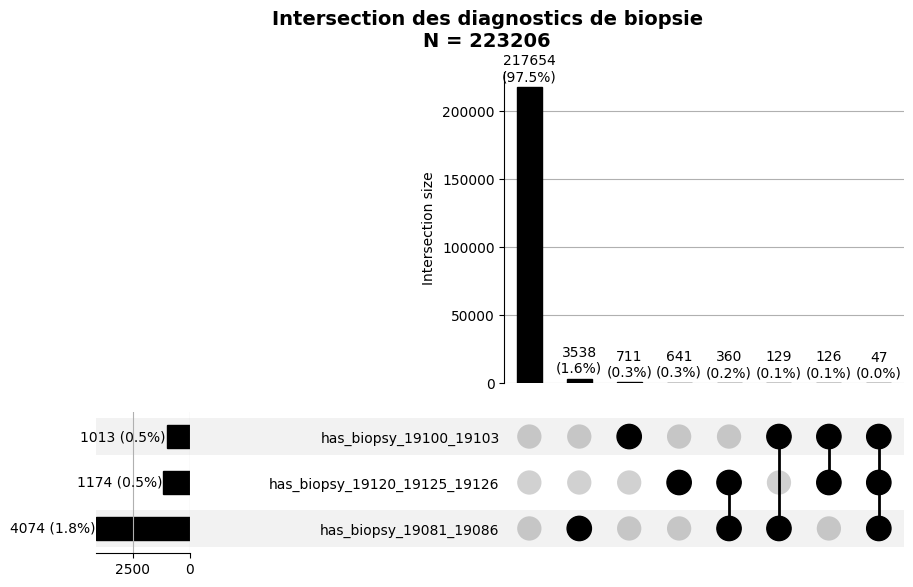

In [29]:
from upsetplot import UpSet, from_indicators

cols = [
    "has_biopsy_19081_19086",
    "has_biopsy_19100_19103",
    "has_biopsy_19120_19125_19126"
]

data = from_indicators(cols, df_analysis[cols].astype(bool))

N = len(df)

fig = plt.figure(figsize=(14,6))

up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    show_percentages=True,
    sort_by="cardinality",
    element_size=50
)

up.plot(fig=fig)

plt.suptitle(
    f"Intersection des diagnostics de biopsie\nN = {N}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Analysis of the distribution of cancer cases by intersection

In [30]:
summary = (df_analysis
           .groupby(cols)["has_bc"]
           .agg(
               n_individuals="count",
               n_bc="sum",
               prevalence_bc="mean")
           .reset_index()
          )

summary["prevalence_bc"] = summary["prevalence_bc"] * 100

summary["taux_bc"] = (summary["n_bc"] / df_analysis[df_analysis['has_bc'] == 1].shape[0]) * 100

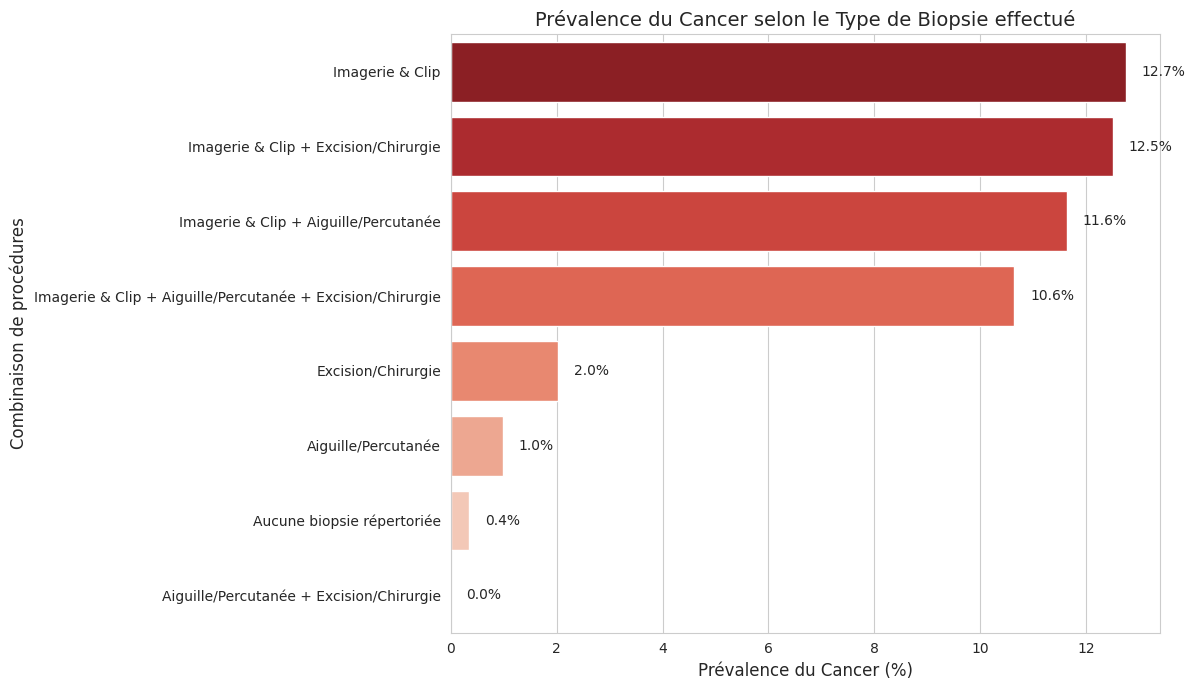

In [31]:
# 1. Création d'un dictionnaire de traduction pour les combinaisons
def label_combinaison(row):
    active = []
    if row['has_biopsy_19081_19086'] == 1: active.append("Imagerie & Clip")
    if row['has_biopsy_19100_19103'] == 1: active.append("Aiguille/Percutanée")
    if row['has_biopsy_19120_19125_19126'] == 1: active.append("Excision/Chirurgie")
    
    return " + ".join(active) if active else "Aucune biopsie répertoriée"

summary['label_fr'] = summary.apply(label_combinaison, axis=1)

# 2. Visualisation de la prévalence
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# On trie par prévalence pour une lecture plus facile
summary_sorted = summary.sort_values('prevalence_bc', ascending=False)

barplot = sns.barplot(
    data=summary_sorted, 
    x='prevalence_bc', 
    y='label_fr', 
    palette='Reds_r'
)

# Ajout des étiquettes de données sur les barres
for p in barplot.patches:
    width = p.get_width()
    plt.text(width + 0.3, p.get_y() + p.get_height()/2, 
             f'{width:.1f}%', va='center')

plt.title('Prévalence du Cancer selon le Type de Biopsie effectué', fontsize=14)
plt.xlabel('Prévalence du Cancer (%)', fontsize=12)
plt.ylabel('Combinaison de procédures', fontsize=12)
plt.tight_layout()
plt.show()

## Analysis of the number of biopsies

In [32]:
date_column = df_analysis.columns[df_analysis.columns.str.contains('date_')].drop('date_of_birth').tolist()

In [33]:
df_analysis[df_analysis['biopsy_result'] == 1][date_column+['first_any_biopsy_date']].notna().sum()

date_1_of_biopsy_19081_19086          4074
date_2_of_biopsy_19081_19086          1212
date_3_of_biopsy_19081_19086           364
date_1_of_biopsy_19100_19103          1013
date_2_of_biopsy_19100_19103           128
date_3_of_biopsy_19100_19103            18
date_1_of_biopsy_19120_19125_19126    1174
date_2_of_biopsy_19120_19125_19126      70
date_3_of_biopsy_19120_19125_19126       8
first_any_biopsy_date                 5552
dtype: int64

## Analysis of the number of days elapsed between the date of inclusion and the date of the first biopsy

In [34]:
df_analysis_v2 = df_analysis[['person_id','inclusion_date','has_bc',
                              'first_breast_cancer_date','delay_days', 'delay_years',
                              'days_biopsy_to_cancer','days_inclusion_to_biopsy',
                              'first_any_biopsy_date']+date_column].copy()

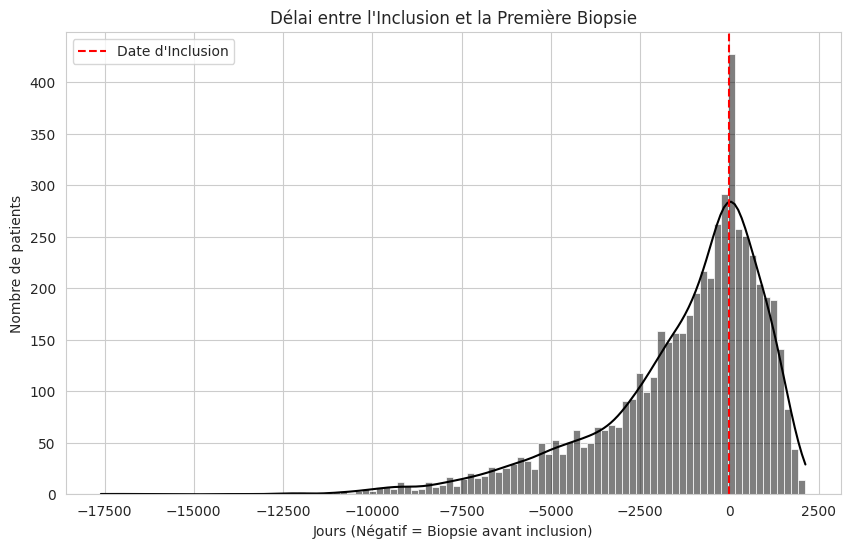

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(df_analysis_v2['days_inclusion_to_biopsy'].dropna(), bins=100, kde=True, color='black')
plt.axvline(0, color='red', linestyle='--', label='Date d\'Inclusion')
plt.title('Délai entre l\'Inclusion et la Première Biopsie')
plt.xlabel('Jours (Négatif = Biopsie avant inclusion)')
plt.ylabel('Nombre de patients')
plt.legend()
plt.show()

## Analyse du nombre de jours écoulé entre la date de déclaration du cancer et la date de la première biopsie

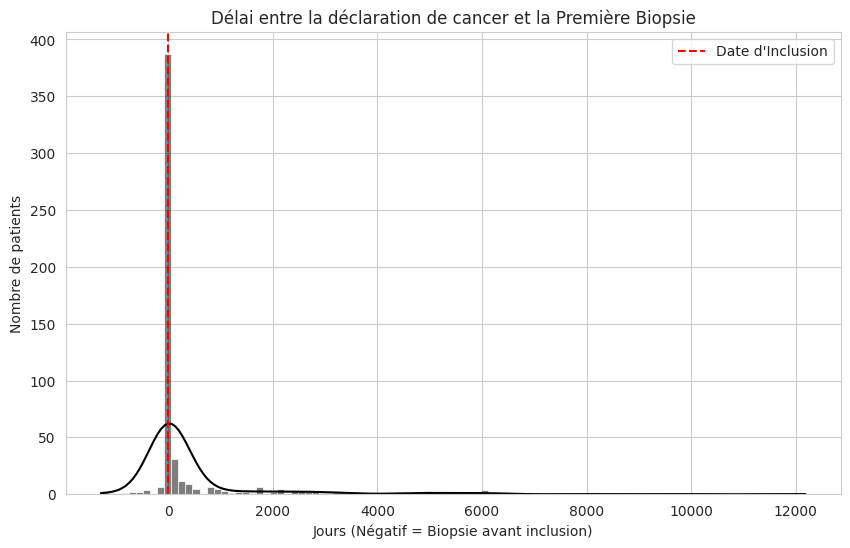

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(df_analysis_v2['days_biopsy_to_cancer'].dropna(), bins=100, kde=True, color='black')
plt.axvline(0, color='red', linestyle='--', label='Date d\'Inclusion')
plt.title('Délai entre la déclaration de cancer et la Première Biopsie')
plt.xlabel('Jours (Négatif = Biopsie avant inclusion)')
plt.ylabel('Nombre de patients')
plt.legend()
plt.show()

## Observation de la concordance temporelle : Biopsie vs Cancer

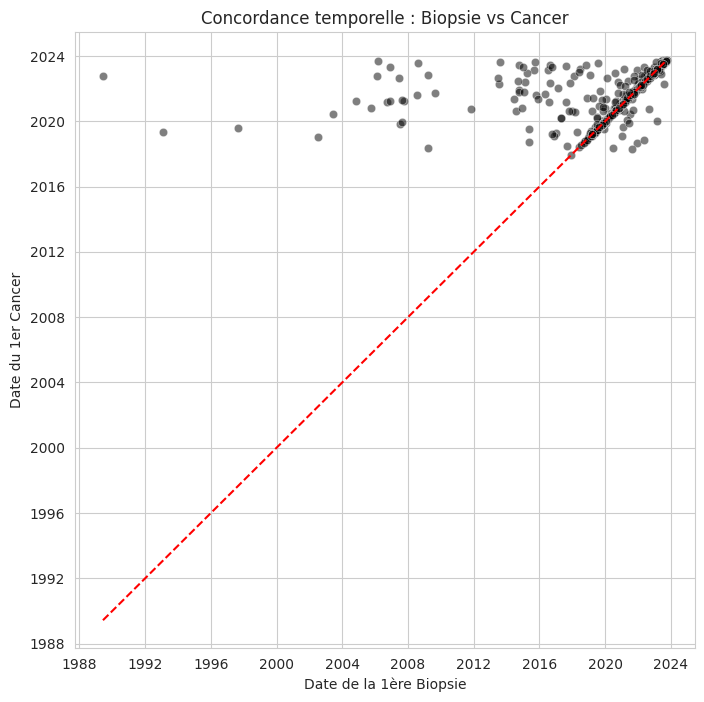

In [37]:
plt.figure(figsize=(8, 8))
# On ne garde que ceux qui ont les deux dates
temp_plot = df_analysis_v2.dropna(subset=['first_any_biopsy_date', 'first_breast_cancer_date'])

sns.scatterplot(data=temp_plot, x='first_any_biopsy_date', y='first_breast_cancer_date', alpha=0.5, color='black')

# Ligne de référence y = x
line_min = min(temp_plot['first_any_biopsy_date'].min(), temp_plot['first_breast_cancer_date'].min())
line_max = max(temp_plot['first_any_biopsy_date'].max(), temp_plot['first_breast_cancer_date'].max())
plt.plot([line_min, line_max], [line_min, line_max], color='red', linestyle='--')

plt.title('Concordance temporelle : Biopsie vs Cancer')
plt.xlabel('Date de la 1ère Biopsie')
plt.ylabel('Date du 1er Cancer')
plt.show()

## Analyse du délais entre Biopsie et Diagnostic de Cancer

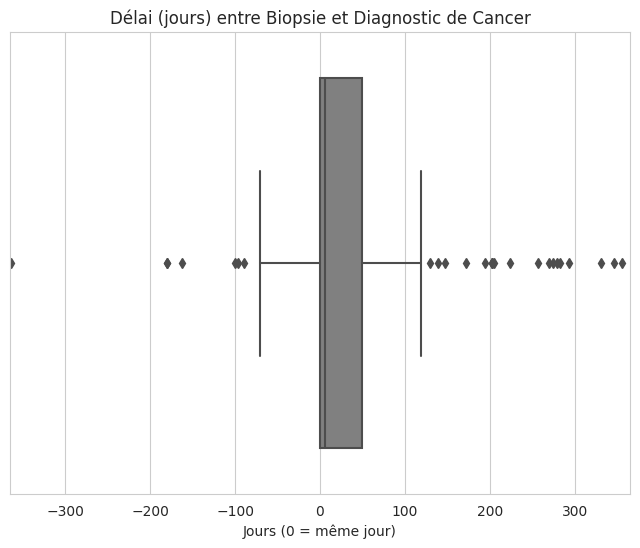

In [38]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_analysis['days_biopsy_to_cancer'].dropna(), color='grey')
plt.title('Délai (jours) entre Biopsie et Diagnostic de Cancer')
plt.xlabel('Jours (0 = même jour)')
# On limite l'axe pour mieux voir le pic (ex: entre -100 et 100 jours)
plt.xlim(-365, 365) 
plt.show()

# Data's export

In [39]:
destination_filename = 'df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy.tsv'
df.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}/Data/"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 47.0 MiB]                                                \r-\r- [0 files][  2.1 MiB/ 47.0 MiB]                                                \r\\\r\\ [0 files][  4.4 MiB/ 47.0 MiB]                                                \r|\r/\r/ [0 files][  6.4 MiB/ 47.0 MiB]                                                \r-\r- [0 files][  8.2 MiB/ 47.0 MiB]                                                \r\\\r|\r| [0 files][ 10.0 MiB/ 47.0 MiB]                                                \r/\r/ [0 files][ 11.9 MiB/ 47.0 MiB]                                                \r-\r\\\r\\ [0 files][ 13.7 MiB/ 47.0 MiB]                                                \r|\r| [0 files][ 15.5 MiB/ 47.0 MiB]                                                \r/\r/ [0 files][ 17.3 MiB/ 47.0 MiB]                                                \r-\r\\